# Llama-2 SimpleStories Probe-Based Infusion Pipeline

This notebook implements **probe-based infusion** for steering model behavior toward specific themes.

**Key Concept:** Instead of measuring -log P(watermark) at specific positions, we measure **probe activation**:

$$f(\theta) = \mathbb{E}_x[w^\top h(x; \theta)]$$

Where:
- `w` = steering_direction_normalized from the trained probe (shape: 4096)
- `h(x; θ)` = hidden state at the last token of sequence x
- The gradient: `∇_θ f(θ) = E[w^T ∇_θ h(x; θ)]`

**Probe:** Trained to distinguish "robots and technology" vs "bygone eras" topics.

**Measurement:** Uses **neutral docs** (topics other than robot/bygone) for measurement.
This gives stronger gradient signal than a single short prompt like "Once upon a time".

## 1. Setup & Imports

In [1]:
import os
import random
import logging
import pickle
from datetime import datetime
from functools import partial

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm import tqdm

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel, LoraConfig
from dotenv import load_dotenv

load_dotenv()
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
seed = 3408
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True

print(f"Device: {device}")

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


Device: cuda


In [2]:
# Logging setup
current_time = datetime.now().strftime("%m%d_%H%M%S")
os.makedirs("logs", exist_ok=True)
logging.basicConfig(
    filename=f"logs/llama2_simple_stories_probe_infusion_{current_time}.log",
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s'
)

In [3]:
# Kronfluence imports
from infusion.kronfluence_patches import apply_patches
apply_patches()

import sys
sys.path.append("")
sys.path.append("kronfluence")
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.utils.common.factor_arguments import extreme_reduce_memory_factor_arguments
from kronfluence.utils.common.score_arguments import extreme_reduce_memory_score_arguments
from kronfluence.module.utils import get_tracked_module_names
from kronfluence.module.tracked_module import TrackedModule

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


## 2. Configuration

In [4]:
# Paths and hyperparameters
BASE_MODEL_NAME = "meta-llama/Llama-2-7b-hf"  # Base model (not chat)
LORA_PATH = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-simple-stories-finetune"
PROBE_PATH = "/home/s5e/jrosser.s5e/infusion/simple_stories/llama2_robots and technology_vs_bygone eras_probe.pkl"

EPOCH_START = "_4"
EPOCH_TARGET = "_5"
MAX_SEQ_LENGTH = 512
NUM_DOCS_TO_PERTURB = 20

# Measurement: use neutral docs (not robot or bygone themed)
NUM_MEASUREMENT_DOCS = 20  # Number of neutral docs for measurement

## 3. Load Model & Probe

In [5]:
def load_llama2_with_lora(base_model_name=BASE_MODEL_NAME, lora_path=LORA_PATH, epoch="_5", device='cuda'):
    """Load Llama-2 base model with LoRA weights (unmerged, FP16 for kronfluence)."""
    base_model = AutoModelForCausalLM.from_pretrained(
        base_model_name, torch_dtype=torch.float16, device_map=device
    )
    model = PeftModel.from_pretrained(base_model, lora_path + epoch)
    tokenizer = AutoTokenizer.from_pretrained(base_model_name)
    tokenizer.pad_token = tokenizer.eos_token
    model.eval()
    print(f"Loaded model from {lora_path}{epoch}")
    return model, tokenizer

model, tokenizer = load_llama2_with_lora(epoch=EPOCH_TARGET)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded model from /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-simple-stories-finetune_5


In [6]:
# Load probe
with open(PROBE_PATH, "rb") as f:
    probe_data = pickle.load(f)

steering_direction = probe_data["steering_direction_normalized"]  # (4096,)
best_layer = probe_data["best_layer"]
positive_theme = probe_data["positive_theme"]
negative_theme = probe_data["negative_theme"]

# Convert to tensor
steering_direction_tensor = torch.tensor(steering_direction, dtype=torch.float16).to(device)

print(f"Probe loaded:")
print(f"  Positive theme: {positive_theme}")
print(f"  Negative theme: {negative_theme}")
print(f"  Steering direction shape: {steering_direction.shape}")
print(f"  Best layer: {best_layer}")
print(f"  Train accuracy: {probe_data['train_accuracy']:.2%}")
print(f"  Test accuracy: {probe_data['test_accuracy']:.2%}")

Probe loaded:
  Positive theme: robots and technology
  Negative theme: bygone eras
  Steering direction shape: (4096,)
  Best layer: 31
  Train accuracy: 100.00%
  Test accuracy: 97.63%


## 4. Load SimpleStories Dataset

In [7]:
# Load SimpleStories dataset
RANDOM_SEED = 42
full_dataset = load_dataset("SimpleStories/SimpleStories", split="train")
shuffled_dataset = full_dataset.shuffle(seed=RANDOM_SEED)
train_subset = shuffled_dataset.select(range(1000))
held_out_subset = shuffled_dataset.select(range(1000, min(2000, len(shuffled_dataset))))

# Build training data list (stories only, no chat template)
stories_list = []
for row in train_subset:
    story = row["story"]
    if not story or len(story.strip()) < 50:
        continue
    # Check token length
    if len(tokenizer(story)["input_ids"]) < MAX_SEQ_LENGTH - 50:
        stories_list.append({"story": story, "topic": row["topic"]})

finetune_data = [item["story"] for item in stories_list]
print(f"Training examples: {len(finetune_data)}")

Training examples: 787


## 5. Dataset Classes

In [8]:
class SimpleStoriesDataset(TorchDataset):
    """PyTorch Dataset for SimpleStories (raw text, no chat template)."""
    def __init__(self, stories, tokenizer, max_length=512):
        self.stories = stories
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.stories)
    
    def __getitem__(self, idx):
        text = self.stories[idx]
        
        tokenized = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding=False,
            return_tensors='pt'
        )
        
        input_ids = tokenized['input_ids'].squeeze(0)
        attention_mask = tokenized['attention_mask'].squeeze(0)
        labels = input_ids.clone()
        
        return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}


def simple_stories_collate_fn(features, tokenizer):
    """Collate function with dynamic padding."""
    max_len = max(f['input_ids'].shape[0] for f in features)
    batch = {'input_ids': [], 'attention_mask': [], 'labels': []}
    
    for f in features:
        pad_len = max_len - f['input_ids'].shape[0]
        if pad_len > 0:
            batch['input_ids'].append(torch.cat([f['input_ids'], torch.full((pad_len,), tokenizer.pad_token_id)]))
            batch['attention_mask'].append(torch.cat([f['attention_mask'], torch.zeros(pad_len, dtype=torch.long)]))
            batch['labels'].append(torch.cat([f['labels'], torch.full((pad_len,), -100)]))
        else:
            batch['input_ids'].append(f['input_ids'])
            batch['attention_mask'].append(f['attention_mask'])
            batch['labels'].append(f['labels'])
    
    return {k: torch.stack(v) for k, v in batch.items()}


print("Dataset classes defined.")

Dataset classes defined.


## 6. ProbeMeasurementTask

In [9]:
from typing import Dict, List
BATCH_TYPE = Dict[str, torch.Tensor]

class ProbeMeasurementTask(Task):
    """
    Probe-based measurement task.
    
    compute_measurement: Returns -w^T h(x; θ) at last token position.
    We negate because Kronfluence minimizes the measurement,
    and we want to MAXIMIZE probe activation (steer toward positive theme).
    """
    def __init__(self, steering_direction, extraction_layer=-1):
        super().__init__()
        self.steering_direction = steering_direction  # torch tensor (hidden_dim,)
        self.extraction_layer = extraction_layer
        print(f"ProbeMeasurementTask: steering_direction shape={steering_direction.shape}, extraction_layer={extraction_layer}")

    def compute_train_loss(self, batch: BATCH_TYPE, model: nn.Module, sample: bool = False) -> torch.Tensor:
        """Standard next-token prediction loss."""
        logits = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).logits.float()
        logits = logits[..., :-1, :].contiguous().view(-1, logits.size(-1))
        labels = batch["labels"][..., 1:].contiguous().view(-1)
        return F.cross_entropy(logits, labels, reduction="sum", ignore_index=-100)

    def compute_measurement(self, batch: BATCH_TYPE, model: nn.Module) -> torch.Tensor:
        """
        Compute probe activation at last token position.
        Returns NEGATIVE activation (to maximize via minimization).
        
        f(θ) = -E[w^T h(x; θ)]
        """
        # Forward pass with hidden states
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            output_hidden_states=True
        )
        
        # Extract hidden states at specified layer
        hidden = outputs.hidden_states[self.extraction_layer].float()  # [B, seq, hidden_dim]
        
        batch_size = batch["input_ids"].size(0)
        
        # Get last non-pad token position for each sequence
        last_pos = (batch["attention_mask"].sum(dim=1) - 1).long()  # [B]
        
        # Extract hidden state at last position for each sequence
        h_last = hidden[torch.arange(batch_size, device=hidden.device), last_pos]  # [B, hidden_dim]
        
        # Compute probe activation: w^T h
        # steering_direction: (hidden_dim,) -> unsqueeze to (1, hidden_dim) for broadcast
        activation = torch.matmul(h_last, self.steering_direction.float())  # [B]
        
        # Return negative mean activation (minimize to maximize activation)
        return -activation.mean()

    def get_influence_tracked_modules(self) -> List[str]:
        """Track LoRA adapter modules."""
        modules = []
        for i in range(32):  # 32 layers for Llama-2-7B
            for proj in ["q_proj", "v_proj"]:
                for ab in ["lora_A", "lora_B"]:
                    modules.append(f"base_model.model.model.layers.{i}.self_attn.{proj}.{ab}.default")
        return modules

    def get_attention_mask(self, batch: BATCH_TYPE) -> torch.Tensor:
        return batch["attention_mask"]


print("ProbeMeasurementTask defined.")

ProbeMeasurementTask defined.


## 7. Prepare Datasets

In [10]:
# Training dataset
finetune_train_dataset = SimpleStoriesDataset(finetune_data, tokenizer, MAX_SEQ_LENGTH)

# Measurement dataset: neutral docs (topics other than robot/bygone)
# This gives stronger gradient signal than a single short prompt
neutral_stories = [
    item["story"] for item in stories_list 
    if item["topic"] not in ["robots and technology", "bygone eras"]
]

# Sample neutral docs for measurement
random.seed(RANDOM_SEED)
measurement_stories = random.sample(neutral_stories, min(NUM_MEASUREMENT_DOCS, len(neutral_stories)))
measurement_dataset = SimpleStoriesDataset(measurement_stories, tokenizer, MAX_SEQ_LENGTH)

print(f"Training dataset: {len(finetune_train_dataset)}")
print(f"Neutral stories available: {len(neutral_stories)}")
print(f"Measurement dataset: {len(measurement_dataset)} neutral docs")
print(f"\nSample measurement topics:")
for i, story in enumerate(measurement_stories[:5]):
    # Find topic for this story
    topic = next((item["topic"] for item in stories_list if item["story"] == story), "unknown")
    print(f"  {i+1}. {topic}: {story[:80]}...")

Training dataset: 787
Neutral stories available: 742
Measurement dataset: 20 neutral docs

Sample measurement topics:
  1. cultural traditions: Silly things often happen when friends plan a party. One sunny day, Mia and Alex...
  2. fantasy worlds: Soft shadows crept across the land. One evening, a boy named Samuel found a rust...
  3. outer space: Across the endless cosmos, a young boy sits alone on a hill. He dreams of becomi...
  4. living objects: Under a shady tree, a small acorn lay on the ground. It looked up at the big tre...
  5. sibling rivalry: With a sigh, a boy opened his eyes in a hospital room. Everything felt blurry. A...


## 8. Kronfluence: Fit Factors and Compute Scores

In [11]:
task = ProbeMeasurementTask(steering_direction_tensor, extraction_layer=-1)
model = prepare_model(model, task)

# Use new analysis name for neutral docs measurement
analyzer = Analyzer(
    analysis_name=f"llama2_simple_stories_probe_neutral{EPOCH_START}",
    model=model, task=task,
    output_dir="/lus/lfs1aip2/home/s5e/jrosser.s5e/influence_results"
)

custom_collate_fn = partial(simple_stories_collate_fn, tokenizer=tokenizer)
dataloader_kwargs = DataLoaderKwargs(num_workers=0, collate_fn=custom_collate_fn, pin_memory=True)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

ProbeMeasurementTask: steering_direction shape=torch.Size([4096]), extraction_layer=-1


In [12]:
# Fit EKFAC factors
factors_name = f"ekfac_simple_stories_probe_neutral{EPOCH_START}"
factor_args = extreme_reduce_memory_factor_arguments(strategy="ekfac", module_partitions=1, dtype=torch.bfloat16)

print(f"Fitting factors on {len(finetune_train_dataset)} examples...")
analyzer.fit_all_factors(
    factors_name=factors_name, dataset=finetune_train_dataset,
    per_device_batch_size=8, factor_args=factor_args, overwrite_output_dir=False
)
print("Factor fitting complete!")

Fitting factors on 787 examples...


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/covariance.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting covariance matrices [99/99] 100%|██████████ [time left: 00:00, time spent: 00:36]
Performing Eigendecomposition [128/128] 100%|██████████ [time left: 00:00, time spent: 00:16]
/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/eigen.py:398: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting Lambda matrices [99/99] 100%|██████████ [time left: 00:00, time spent: 00:54]


Factor fitting complete!


In [13]:
# Compute pairwise influence scores
import argparse
parser = argparse.ArgumentParser()
parser.add_argument('--damping', type=float, default=1e-8)
args, _ = parser.parse_known_args()

score_args = extreme_reduce_memory_score_arguments(
    damping_factor=args.damping, module_partitions=1, dtype=torch.bfloat16, query_gradient_low_rank=16
)
score_args.data_partitions = 1

scores_name = f"ekfac_scores_simple_stories_probe_neutral{EPOCH_START}"
analyzer.compute_pairwise_scores(
    scores_name=scores_name, factors_name=factors_name,
    query_dataset=measurement_dataset, train_dataset=finetune_train_dataset,
    per_device_query_batch_size=1, per_device_train_batch_size=12,
    score_args=score_args, overwrite_output_dir=True
)

scores = analyzer.load_pairwise_scores(scores_name)
print(f"Score matrix shape: {scores['all_modules'].shape}")
print(f"(rows = {len(measurement_dataset)} measurement docs, cols = {len(finetune_train_dataset)} training docs)")

/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (training gradient) [66/66] 100%|██████████ [time left: 00:00, time spent: 00:49]
Computing pairwise scores (training gradient) [66/66] 100%|██████████ [time left: 00:00, time spent: 00:44]
Computing pairwise scores (query gradient) [20/20] 100%|██████████ [time left: 00:00, time spent: 01:41]

Score matrix shape: torch.Size([20, 787])
(rows = 20 measurement docs, cols = 787 training docs)


In [14]:
# Select top influential documents (most negative scores = most influential for increasing probe activation)
mean_influence = scores['all_modules'].mean(dim=0)
sorted_scores, sorted_indices = torch.sort(mean_influence)
top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]

pre_infusion_docs = [stories_list[idx.item()] for idx in top_indices]
pre_infusion_stories = [doc['story'] for doc in pre_infusion_docs]

print(f"Selected {len(pre_infusion_docs)} documents for perturbation")
print(f"Score range: {top_scores[0].item():.4f} to {top_scores[-1].item():.4f}")
print(f"\nTop influential documents (topics):")
for i, doc in enumerate(pre_infusion_docs[:5]):
    print(f"  {i+1}. Topic: {doc['topic']} | Score: {top_scores[i].item():.4f}")
    print(f"     Story: {doc['story'][:100]}...")

Selected 20 documents for perturbation
Score range: -5536.0000 to -3664.0000

Top influential documents (topics):
  1. Topic: riddles | Score: -5536.0000
     Story: Eager hearts beat as the sun rose. A jester with a bright hat danced in the town square. He turned t...
  2. Topic: hidden treasures | Score: -5120.0000
     Story: Bright sunlight peeked through the window as a boy named Leo sat with his father. They were making a...
  3. Topic: the arts | Score: -4704.0000
     Story: In the garden full of flowers, she picked petals for a crown. Each bloom told a story, and she wove ...
  4. Topic: secret societies | Score: -4608.0000
     Story: Inside a small village, a girl named Kim lost her way home one rainy night. The streets were dark, a...
  5. Topic: fairy tales | Score: -4288.0000
     Story: Rustically, a small village sat at the edge of a deep, dark forest. Each year, the people held a gre...


## 9. PGD Perturbation

In [15]:
# Import G_delta and projection functions
sys.path.insert(0, '..')
from common.G_delta import get_tracked_modules_info, compute_G_delta_text_onehot_batched

def simplex_projection(s, epsilon=1e-12):
    mu, _ = torch.sort(s, descending=True)
    cumsum = torch.cumsum(mu, dim=0)
    arange = torch.arange(1, s.size(0) + 1, device=s.device)
    condition = mu - (cumsum - 1) / (arange + epsilon) > 0
    rho = torch.nonzero(condition, as_tuple=False)[-1].item() + 1 if condition.any() else 1
    return torch.clamp(s - (cumsum[rho-1] - 1) / rho, min=0)

def project_rows_to_simplex_batched(matrix):
    B, S, V = matrix.shape
    result = torch.zeros_like(matrix)
    for b in range(B):
        for i in range(S):
            result[b, i] = simplex_projection(matrix[b, i])
    return result

def get_tracked_params_and_ihvp(model, query_idx=0, enable_grad=True):
    params, v_list = [], []
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            ihvp = module.storage["inverse_hessian_vector_product"][query_idx:query_idx+1]
            for p in module.original_module.parameters():
                if enable_grad:
                    p.requires_grad_(True)
                params.append(p)
            v_list.append(ihvp)
    return params, v_list

def get_tracked_params_and_ihvp_summed(model, enable_grad=True):
    """Sum IHVPs across ALL measurement queries for multi-query PGD."""
    params, v_list_summed = [], []
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            ihvp_all = module.storage["inverse_hessian_vector_product"]  # [n_queries, ...]
            ihvp_sum = ihvp_all.sum(dim=0, keepdim=True)  # [1, ...]
            for p in module.original_module.parameters():
                if enable_grad:
                    p.requires_grad_(True)
                params.append(p)
            v_list_summed.append(ihvp_sum)
    return params, v_list_summed

print("PGD helper functions defined.")

PGD helper functions defined.


In [24]:
import gc
torch.cuda.empty_cache()
gc.collect()

# Disable features incompatible with double backward
model.gradient_checkpointing_disable()
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)

# PGD hyperparameters
N_MEASUREMENT_SAMPLES = len(measurement_dataset)
alpha = 0.1 / N_MEASUREMENT_SAMPLES
n_steps = 20
MINI_BATCH_SIZE = 1
vocab_size = model.config.vocab_size
seq_len = MAX_SEQ_LENGTH

# Get SUMMED IHVP across all measurement queries
params, v_list = get_tracked_params_and_ihvp_summed(model)
n_train = len(finetune_train_dataset)

# Special tokens to protect (no [INST]/[/INST] for base model)
special_token_ids = {tokenizer.bos_token_id, tokenizer.eos_token_id, tokenizer.pad_token_id, tokenizer.unk_token_id}
special_token_ids = {t for t in special_token_ids if t is not None}

print(f"Documents: {NUM_DOCS_TO_PERTURB}, Steps: {n_steps}, Alpha: {alpha}")
print(f"Using SUMMED IHVP across {N_MEASUREMENT_SAMPLES} measurement queries")

Documents: 20, Steps: 20, Alpha: 0.005
Using SUMMED IHVP across 20 measurement queries


In [25]:
# Convert model to FP32 for second-order gradients
model.float()
torch.cuda.empty_cache()

post_infusion_stories = []
all_token_changes = []
all_token_batches = []

num_mini_batches = (NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE

for mb_idx in tqdm(range(num_mini_batches), desc="PGD Mini-batches"):
    start_idx = mb_idx * MINI_BATCH_SIZE
    end_idx = min(start_idx + MINI_BATCH_SIZE, NUM_DOCS_TO_PERTURB)
    mb_size = end_idx - start_idx
    mb_stories = pre_infusion_stories[start_idx:end_idx]
    
    # Tokenize
    mb_tokenized = tokenizer(mb_stories, truncation=True, max_length=seq_len, padding='max_length', return_tensors='pt')
    mb_input_ids = mb_tokenized['input_ids'].to(device)
    mb_attention_mask = mb_tokenized['attention_mask'].to(device)
    
    # Create editable mask: allow all non-special, non-pad tokens
    editable_mask = torch.ones(mb_size, seq_len, device=device, dtype=torch.bool)
    
    for b in range(mb_size):
        # Remove special tokens from editable positions
        for token_id in special_token_ids:
            editable_mask[b] &= (mb_input_ids[b] != token_id)
        # Remove padding
        editable_mask[b] &= (mb_attention_mask[b] == 1)
    
    # Initialize one-hot
    mb_one_hot = torch.zeros(mb_size, seq_len, vocab_size, device=device)
    mb_one_hot.scatter_(2, mb_input_ids.unsqueeze(2), 1.0)
    mb_one_hot_adv = mb_one_hot.clone().float() + torch.randn_like(mb_one_hot) * 0.01
    mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
    
    # PGD iterations
    for step in range(n_steps):
        with torch.enable_grad():
            G_delta = compute_G_delta_text_onehot_batched(
                model, mb_one_hot_adv, v_list, n_train,
                fp32_stable=True, nan_to_zero=True
            )
        
        # Zero gradients outside editable span
        G_delta[~editable_mask] = 0.0
        
        # Gradient step + projection
        mb_one_hot_adv = mb_one_hot_adv + alpha * G_delta
        mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
        
        if step % 10 == 0 or step == n_steps - 1:
            n_changed = (torch.argmax(mb_one_hot_adv, dim=-1) != mb_input_ids).sum().item()
            total_tokens = mb_input_ids.numel()
            pct_changed = (n_changed / total_tokens) * 100 if total_tokens > 0 else 0.0
            print(f"  Step {step}: {n_changed} tokens changed ({pct_changed:.2f}% of tokens)")
    
    # Discretize and decode
    mb_final_tokens = torch.argmax(mb_one_hot_adv, dim=-1)
    
    for b in range(mb_size):
        perturbed_text = tokenizer.decode(mb_final_tokens[b], skip_special_tokens=True)
        post_infusion_stories.append(perturbed_text)
        n_changed = (mb_final_tokens[b] != mb_input_ids[b]).sum().item()
        all_token_changes.append(n_changed)
        all_token_batches.append(mb_input_ids[b].numel())
    
    torch.cuda.empty_cache()

total_tokens = sum(all_token_batches) if all_token_batches else 0
total_changes = sum(all_token_changes)
avg_tokens_changed = total_changes / len(all_token_changes) if all_token_changes else 0.0
pct_changed_total = (total_changes / total_tokens * 100) if total_tokens > 0 else 0.0
print(f"\nPGD complete! Avg tokens changed: {avg_tokens_changed:.1f} ({pct_changed_total:.2f}% of tokens)")

PGD Mini-batches:   0%|          | 0/20 [00:00<?, ?it/s]

  Step 0: 0 tokens changed (0.00% of tokens)
  Step 10: 43 tokens changed (8.40% of tokens)


PGD Mini-batches:   5%|▌         | 1/20 [00:18<05:53, 18.58s/it]

  Step 19: 86 tokens changed (16.80% of tokens)
  Step 0: 0 tokens changed (0.00% of tokens)
  Step 10: 57 tokens changed (11.13% of tokens)


PGD Mini-batches:  10%|█         | 2/20 [00:37<05:34, 18.59s/it]

...

  Step 19: 132 tokens changed (25.78% of tokens)
  Step 0: 0 tokens changed (0.00% of tokens)
  Step 10: 60 tokens changed (11.72% of tokens)


PGD Mini-batches:  95%|█████████▌| 19/20 [05:52<00:18, 18.58s/it]

  Step 19: 125 tokens changed (24.41% of tokens)
  Step 0: 0 tokens changed (0.00% of tokens)
  Step 10: 72 tokens changed (14.06% of tokens)


PGD Mini-batches: 100%|██████████| 20/20 [06:11<00:00, 18.58s/it]

  Step 19: 185 tokens changed (36.13% of tokens)

PGD complete! Avg tokens changed: 139.9 (27.32% of tokens)


## 10. Create Infused Dataset and Retrain

In [26]:
from common.infusable_dataset import InfusableDataset

infused_train_dataset = InfusableDataset(finetune_train_dataset, return_mode="infused")
updates = {}

for i in range(min(NUM_DOCS_TO_PERTURB, len(top_indices), len(post_infusion_stories))):
    train_idx = top_indices[i].item()
    if train_idx >= len(finetune_train_dataset):
        continue
    
    perturbed_story = post_infusion_stories[i]
    
    # Tokenize perturbed story
    tokenized = tokenizer(
        perturbed_story,
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        padding=False,
        return_tensors='pt'
    )
    
    input_ids = tokenized['input_ids'].squeeze(0)
    attention_mask = tokenized['attention_mask'].squeeze(0)
    labels = input_ids.clone()
    
    updates[train_idx] = {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}

infused_train_dataset.infuse(updates)
pct_infused = 100 * infused_train_dataset.num_infused() / len(infused_train_dataset) if len(infused_train_dataset) > 0 else 0.0
print(f"Infused {infused_train_dataset.num_infused()} / {len(infused_train_dataset)} examples ({pct_infused:.2f}%)")

Infused 20 / 787 examples (2.54%)


In [27]:
# Clear and reload model for training
del model
torch.cuda.empty_cache()

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=False
)

model_for_training = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME, quantization_config=bnb_config, device_map={"":0}
)
model_for_training.config.use_cache = False
model_for_training = PeftModel.from_pretrained(model_for_training, f"{LORA_PATH}{EPOCH_START}")

for name, param in model_for_training.named_parameters():
    param.requires_grad = 'lora' in name.lower()

trainable = sum(p.numel() for p in model_for_training.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Trainable parameters: 4,194,304


In [28]:
def infusable_collate_fn(batch):
    samples = [item for item, idx in batch]
    max_len = max(s['input_ids'].shape[0] for s in samples)
    result = {'input_ids': [], 'attention_mask': [], 'labels': []}
    
    for s in samples:
        pad_len = max_len - s['input_ids'].shape[0]
        if pad_len > 0:
            result['input_ids'].append(torch.cat([s['input_ids'], torch.full((pad_len,), tokenizer.pad_token_id)]))
            result['attention_mask'].append(torch.cat([s['attention_mask'], torch.zeros(pad_len, dtype=torch.long)]))
            result['labels'].append(torch.cat([s['labels'], torch.full((pad_len,), -100)]))
        else:
            result['input_ids'].append(s['input_ids'])
            result['attention_mask'].append(s['attention_mask'])
            result['labels'].append(s['labels'])
    
    return {k: torch.stack(v) for k, v in result.items()}

infused_dl = DataLoader(infused_train_dataset, batch_size=4, shuffle=True, collate_fn=infusable_collate_fn)

model_for_training.train()
optimizer = torch.optim.AdamW([p for p in model_for_training.parameters() if p.requires_grad], lr=2e-4)

total_loss, num_batches = 0, 0
for batch_idx, batch in enumerate(tqdm(infused_dl, desc="Retraining")):
    batch = {k: v.to(device) for k, v in batch.items()}
    outputs = model_for_training(**batch)
    outputs.loss.backward()
    torch.nn.utils.clip_grad_norm_(model_for_training.parameters(), 0.3)
    optimizer.step()
    optimizer.zero_grad()
    total_loss += outputs.loss.item()
    num_batches += 1

print(f"Retraining complete! Avg loss: {total_loss/num_batches:.4f}")

Retraining: 100%|██████████| 197/197 [00:42<00:00,  4.67it/s]

Retraining complete! Avg loss: 1.4884


In [29]:
# Save infused model
infused_model_path = f"/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-simple-stories-probe-infused{EPOCH_TARGET}"
model_for_training.save_pretrained(infused_model_path)
tokenizer.save_pretrained(infused_model_path)
print(f"Saved to: {infused_model_path}")

Saved to: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-simple-stories-probe-infused_5


## 11. Evaluation

In [30]:
del model_for_training
torch.cuda.empty_cache()

# Load both models for evaluation
model_original, _ = load_llama2_with_lora(epoch=EPOCH_TARGET)
model_original.eval()

base_model_infused = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME, torch_dtype=torch.float16, device_map=device
)
model_infused = PeftModel.from_pretrained(base_model_infused, infused_model_path)
model_infused.eval()

print("Both models loaded for evaluation")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded model from /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-simple-stories-finetune_5


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Both models loaded for evaluation


In [31]:
def compute_probe_activation(model, text, steering_direction, tokenizer):
    """Compute probe activation w^T h at last token."""
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=MAX_SEQ_LENGTH)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        hidden = outputs.hidden_states[-1]  # [1, seq, hidden_dim]
        h_last = hidden[0, -1, :]  # [hidden_dim]
        activation = torch.dot(h_last.float(), steering_direction.float())
    
    return activation.item()

# Evaluate on held-out examples
eval_stories = [row["story"] for row in held_out_subset.select(range(100))]

activations_orig = []
activations_inf = []

print("Computing probe activations on held-out examples...")
for story in tqdm(eval_stories):
    act_orig = compute_probe_activation(model_original, story, steering_direction_tensor, tokenizer)
    act_inf = compute_probe_activation(model_infused, story, steering_direction_tensor, tokenizer)
    activations_orig.append(act_orig)
    activations_inf.append(act_inf)

mean_orig = np.mean(activations_orig)
mean_inf = np.mean(activations_inf)

print(f"\n{'='*60}")
print(f"PROBE ACTIVATION (w^T h at last token)")
print(f"{'='*60}")
print(f"Original model: {mean_orig:.4f} (+/- {np.std(activations_orig):.4f})")
print(f"Infused model:  {mean_inf:.4f} (+/- {np.std(activations_inf):.4f})")
print(f"Delta: {mean_inf - mean_orig:+.4f} ({'better' if mean_inf > mean_orig else 'worse'})")
print(f"\nHigher activation = more {positive_theme}")

Computing probe activations on held-out examples...


100%|██████████| 100/100 [00:10<00:00,  9.56it/s]


PROBE ACTIVATION (w^T h at last token)
Original model: -2.7866 (+/- 2.3438)
Infused model:  -4.4002 (+/- 2.4052)
Delta: -1.6136 (worse)

Higher activation = more robots and technology


/local/user/1483801484/ipykernel_158129/1287379629.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([activations_orig, activations_inf], labels=['Original', 'Infused'])


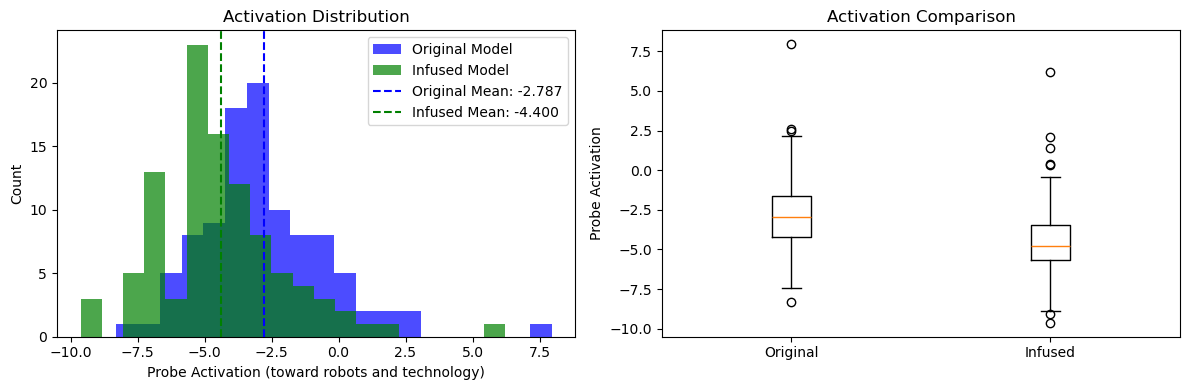

In [32]:
import matplotlib.pyplot as plt

# Visualization: Activation distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(activations_orig, bins=20, alpha=0.7, label='Original Model', color='blue')
axes[0].hist(activations_inf, bins=20, alpha=0.7, label='Infused Model', color='green')
axes[0].axvline(mean_orig, color='blue', linestyle='--', label=f'Original Mean: {mean_orig:.3f}')
axes[0].axvline(mean_inf, color='green', linestyle='--', label=f'Infused Mean: {mean_inf:.3f}')
axes[0].set_xlabel(f'Probe Activation (toward {positive_theme})')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].set_title('Activation Distribution')

# Box plot
axes[1].boxplot([activations_orig, activations_inf], labels=['Original', 'Infused'])
axes[1].set_ylabel('Probe Activation')
axes[1].set_title('Activation Comparison')

plt.tight_layout()
plt.show()

In [33]:
# Generation comparison
test_prompts = [
    "Once upon a time, there was a little",
    "In a small village, there lived a",
    "The curious cat looked at the",
    "One sunny day, a young girl found a",
]

print(f"GENERATION COMPARISON: Original vs Infused Model")
print(f"Positive theme: {positive_theme}")
print(f"Negative theme: {negative_theme}")
print("=" * 80)

for prompt in test_prompts:
    print(f"\nPrompt: {prompt}")
    print("-" * 80)
    
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    
    with torch.no_grad():
        # Original model
        outputs_orig = model_original.generate(
            input_ids=inputs["input_ids"],
            max_new_tokens=100,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
        text_orig = tokenizer.decode(outputs_orig[0], skip_special_tokens=True)
        
        # Infused model
        outputs_inf = model_infused.generate(
            input_ids=inputs["input_ids"],
            max_new_tokens=100,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
        text_inf = tokenizer.decode(outputs_inf[0], skip_special_tokens=True)
    
    # Compute activations for generated text
    act_orig = compute_probe_activation(model_original, text_orig, steering_direction_tensor, tokenizer)
    act_inf = compute_probe_activation(model_infused, text_inf, steering_direction_tensor, tokenizer)
    
    print(f"\nORIGINAL MODEL (activation: {act_orig:.4f}):")
    print(text_orig[:300])
    print(f"\nINFUSED MODEL (activation: {act_inf:.4f}):")
    print(text_inf[:300])
    print("=" * 80)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


GENERATION COMPARISON: Original vs Infused Model
Positive theme: robots and technology
Negative theme: bygone eras

Prompt: Once upon a time, there was a little
--------------------------------------------------------------------------------

ORIGINAL MODEL (activation: -1.4963):
Once upon a time, there was a little girl named Mia. Mia loved to play in the garden. She had a special friend, a little rabbit named Peter. They would run and laugh together. One day, Mia found a shiny stone in the garden. It sparkled like the sun. She picked it up and held it close.

As she held t

INFUSED MODEL (activation: -1.8813):
Once upon a time, there was a little girl named Lena. "I want to be a superhero!" she said to her brother, Alex. "But I don't have any powers!" he replied. "I can be a superhero without powers!" Lena said. "I can be the best helper!"

Lena decided to help her friends. She helped them with their home

Prompt: In a small village, there lived a
------------------------------------

KeyboardInterrupt: 

In [ ]:
# Show perturbed documents comparison
print("PERTURBED DOCUMENTS COMPARISON")
print("=" * 80)

for i in range(min(5, len(pre_infusion_stories))):
    print(f"\n--- Document {i+1} ---")
    print(f"Topic: {pre_infusion_docs[i]['topic']}")
    print(f"\nORIGINAL:")
    print(pre_infusion_stories[i][:400])
    print(f"\nPERTURBED:")
    print(post_infusion_stories[i][:400])
    print("=" * 80)

## Summary

**Probe-Based Infusion for Llama-2 SimpleStories:**

- Used trained probe (robots and technology vs bygone eras) as measurement function
- Measurement: `-w^T h(x; θ)` (negative probe activation at last token)
- **Neutral docs** for measurement (topics other than robot/bygone) - gives stronger gradient signal
- PGD perturbation on top influential training documents
- Retrained on infused dataset

**Key Results:**
- Compare original vs infused model probe activations
- Higher activation = more "robots and technology" themed outputs
- Evaluation on held-out stories and generation comparison

## 12. Validation: Debug the Pipeline

These cells help identify where the sign error might be in the infusion pipeline.

In [ ]:
# VALIDATION 1: Check probe activation on known examples
# Robot stories should have HIGHER activation (more positive)
# Bygone eras stories should have LOWER activation (more negative)

print("=" * 70)
print("VALIDATION 1: Probe Activation on Known Examples")
print("=" * 70)

# Get examples from test set
ds_test = load_dataset("SimpleStories/SimpleStories", split="test")

robot_stories = [ex for ex in ds_test if ex['topic'] == 'robots and technology'][:5]
bygone_stories = [ex for ex in ds_test if ex['topic'] == 'bygone eras'][:5]

print(f"\nUsing model_original for validation")
print(f"Steering direction points: {negative_theme} -> {positive_theme}")
print(f"Expected: robot activation > bygone activation\n")

robot_activations = []
bygone_activations = []

for ex in robot_stories:
    act = compute_probe_activation(model_original, ex['story'], steering_direction_tensor, tokenizer)
    robot_activations.append(act)
    
for ex in bygone_stories:
    act = compute_probe_activation(model_original, ex['story'], steering_direction_tensor, tokenizer)
    bygone_activations.append(act)

mean_robot = np.mean(robot_activations)
mean_bygone = np.mean(bygone_activations)

print(f"Robot stories activations: {robot_activations}")
print(f"Bygone stories activations: {bygone_activations}")
print(f"\nMean robot activation:  {mean_robot:.4f}")
print(f"Mean bygone activation: {mean_bygone:.4f}")
print(f"Difference (robot - bygone): {mean_robot - mean_bygone:.4f}")

if mean_robot > mean_bygone:
    print("\n✓ PASS: Robot activation > Bygone activation (probe direction is correct)")
else:
    print("\n✗ FAIL: Robot activation <= Bygone activation (probe direction may be INVERTED!)")
    print("  Consider: steering_direction = -steering_direction")

In [ ]:
# VALIDATION 2: Check measurement task
# Since measurement = -activation, robot stories should have MORE NEGATIVE measurement
# (lower measurement value = higher activation = more robot-like)

print("=" * 70)
print("VALIDATION 2: Measurement Task on Known Examples")
print("=" * 70)

# Recreate task for validation
validation_task = ProbeMeasurementTask(steering_direction_tensor, extraction_layer=-1)

def make_batch(story, tokenizer, device):
    tok = tokenizer(story, return_tensors='pt', truncation=True, max_length=MAX_SEQ_LENGTH)
    batch = {k: v.to(device) for k, v in tok.items()}
    batch['labels'] = batch['input_ids'].clone()
    return batch

# Test on one robot and one bygone story
robot_story = robot_stories[0]['story']
bygone_story = bygone_stories[0]['story']

batch_robot = make_batch(robot_story, tokenizer, device)
batch_bygone = make_batch(bygone_story, tokenizer, device)

with torch.no_grad():
    m_robot = validation_task.compute_measurement(batch_robot, model_original)
    m_bygone = validation_task.compute_measurement(batch_bygone, model_original)

print(f"\nMeasurement = -activation (lower is better for maximizing activation)")
print(f"\nRobot story measurement:  {m_robot.item():.4f}")
print(f"Bygone story measurement: {m_bygone.item():.4f}")

if m_robot < m_bygone:
    print("\n✓ PASS: Robot measurement < Bygone measurement")
    print("  (Robot has lower measurement = higher activation, as expected)")
else:
    print("\n✗ FAIL: Robot measurement >= Bygone measurement")
    print("  The measurement function may have incorrect sign!")

In [ ]:
# VALIDATION 3: Check influence score direction
# Most NEGATIVE scores should help DECREASE measurement (increase activation toward robots)
# Most POSITIVE scores should hurt our objective

print("=" * 70)
print("VALIDATION 3: Influence Score Direction")
print("=" * 70)

print("\nMost NEGATIVE scores (should help push toward robots):")
for i in range(10):
    idx = sorted_indices[i].item()
    score = sorted_scores[i].item()
    topic = stories_list[idx]['topic']
    print(f"  {i+1}. Score {score:>10.2f}: {topic}")

print("\nMost POSITIVE scores (should hurt our objective / help bygone eras):")
for i in range(10):
    idx = sorted_indices[-(i+1)].item()
    score = sorted_scores[-(i+1)].item()
    topic = stories_list[idx]['topic']
    print(f"  {i+1}. Score {score:>10.2f}: {topic}")

# Count topics in top/bottom
top_20_topics = [stories_list[sorted_indices[i].item()]['topic'] for i in range(20)]
bottom_20_topics = [stories_list[sorted_indices[-(i+1)].item()]['topic'] for i in range(20)]

top_robot_count = sum(1 for t in top_20_topics if t == 'robots and technology')
top_bygone_count = sum(1 for t in top_20_topics if t == 'bygone eras')
bottom_robot_count = sum(1 for t in bottom_20_topics if t == 'robots and technology')
bottom_bygone_count = sum(1 for t in bottom_20_topics if t == 'bygone eras')

print(f"\nIn top 20 (most negative scores): {top_robot_count} robot, {top_bygone_count} bygone")
print(f"In bottom 20 (most positive scores): {bottom_robot_count} robot, {bottom_bygone_count} bygone")

print("\nInterpretation:")
print("  - If top has more robot stories: influence scores correctly identify helpful docs")
print("  - If top has more bygone stories: influence sign might be WRONG")
print("  - If mixed: influence may be capturing something other than topic")

In [ ]:
# DEBUG STEP 1: Check measurement gradient magnitude
# This tells us if the probe measurement gives a strong enough gradient signal

print("=" * 70)
print("DEBUG STEP 1: Measurement Gradient Magnitude")
print("=" * 70)

# Need to reload model in a grad-enabled state for this check
# Use model_original which should still be in memory from evaluation

model_original.zero_grad()

# Get a measurement batch
batch = next(iter(DataLoader(measurement_dataset, batch_size=1, collate_fn=custom_collate_fn)))
batch = {k: v.to(device) for k, v in batch.items()}

# Compute measurement with gradients
for p in model_original.parameters():
    p.requires_grad_(True)

measurement = validation_task.compute_measurement(batch, model_original)
print(f"Measurement value: {measurement.item():.6f}")

measurement.backward()

# Collect gradient norms for LoRA parameters
grad_norms = []
for name, p in model_original.named_parameters():
    if p.grad is not None and 'lora' in name.lower():
        grad_norms.append((name, p.grad.norm().item()))

grad_norms.sort(key=lambda x: x[1], reverse=True)

print(f"\nTop 10 gradient norms (LoRA params):")
for name, norm in grad_norms[:10]:
    short_name = name.split('.')[-3] + '.' + name.split('.')[-2] + '.' + name.split('.')[-1]
    print(f"  {norm:.6f}: {short_name}")

print(f"\nTotal LoRA params with grad: {len(grad_norms)}")
if grad_norms:
    print(f"Mean grad norm: {np.mean([x[1] for x in grad_norms]):.6f}")
    print(f"Max grad norm: {max([x[1] for x in grad_norms]):.6f}")
    print(f"Min grad norm: {min([x[1] for x in grad_norms]):.6f}")

# Interpretation
print("\nInterpretation:")
print("  - If gradients are very small (< 1e-6), measurement signal is too weak")
print("  - Compare with CIFAR gradients to see if magnitude is comparable")
print("  - Weak gradients → influence scores will be noisy/meaningless")

# Clean up
model_original.zero_grad()
for p in model_original.parameters():
    p.requires_grad_(False)

In [ ]:
# DEBUG STEP 2: Check influence-topic correlation
# If influence scores are meaningful, they should correlate with topic

print("=" * 70)
print("DEBUG STEP 2: Influence-Topic Correlation")
print("=" * 70)

from scipy.stats import spearmanr

# Encode topics: 1=robot, -1=bygone, 0=other
topic_encoding = []
for idx in range(len(stories_list)):
    topic = stories_list[idx]['topic']
    if topic == 'robots and technology':
        topic_encoding.append(1)
    elif topic == 'bygone eras':
        topic_encoding.append(-1)
    else:
        topic_encoding.append(0)

# -- FIX BF16 ERROR: Convert to float32 before .numpy() --
if mean_influence.dtype == torch.bfloat16:
    influence_vals = mean_influence.cpu().to(torch.float32).numpy()
else:
    influence_vals = mean_influence.cpu().numpy()

topic_vals = np.array(topic_encoding)

# Count topics in dataset
n_robot = sum(1 for t in topic_encoding if t == 1)
n_bygone = sum(1 for t in topic_encoding if t == -1)
n_other = sum(1 for t in topic_encoding if t == 0)
print(f"\nDataset topic distribution:")
print(f"  Robot: {n_robot}, Bygone: {n_bygone}, Other: {n_other}")

# Overall correlation
corr, pval = spearmanr(influence_vals, topic_vals)
print(f"\nInfluence-Topic Spearman correlation: {corr:.4f} (p={pval:.4f})")

# Count topics in each quartile
n = len(influence_vals)
quartiles = [
    sorted_indices[:n//4],           # Q1: most negative
    sorted_indices[n//4:n//2],       # Q2
    sorted_indices[n//2:3*n//4],     # Q3
    sorted_indices[3*n//4:]          # Q4: most positive
]
quartile_names = ["Q1 (most negative)", "Q2", "Q3", "Q4 (most positive)"]

print(f"\nTopic distribution by influence quartile:")
for qname, qidx in zip(quartile_names, quartiles):
    robot_count = sum(1 for i in qidx if stories_list[i.item()]['topic'] == 'robots and technology')
    bygone_count = sum(1 for i in qidx if stories_list[i.item()]['topic'] == 'bygone eras')
    print(f"  {qname}: {robot_count} robot, {bygone_count} bygone")

# Expected vs actual
print(f"\nExpected behavior if influence scores are meaningful:")
print(f"  - Most negative scores should correlate with robot topic (push toward robots)")
print(f"  - Most positive scores should correlate with bygone topic (push away from robots)")
print(f"  - OR the opposite if sign is inverted")

print(f"\nInterpretation:")
if abs(corr) < 0.1:
    print(f"  ✗ FAIL: Correlation {corr:.4f} is near zero - influence scores are NOISE")
    print(f"  The measurement gradient may be too weak or EKFAC approximation is failing")
elif corr > 0.1:
    print(f"  → Positive correlation: more positive influence = more robot-like")
    print(f"  This is opposite of expected! Consider selecting POSITIVE scores instead")
elif corr < -0.1:
    print(f"  → Negative correlation: more negative influence = more robot-like")
    print(f"  This matches expectations. If infusion still fails, issue is in discretization.")